In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split


In [2]:
df=pd.read_csv('titanic_toy.csv')

In [5]:
df.drop(columns=['Family'],inplace=True)

In [6]:
df

,Age,Fare,Survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0
...,...,...,...
886,27.0,13.0000,0
887,19.0,30.0000,1
888,NaN,23.4500,0
889,26.0,NaN,1


In [7]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Survived     0.000000
dtype: float64

In [8]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [10]:
x_train['inpute_age']=x_train['Age']

In [11]:
x_test['impute_age']=x_test['Age']

In [12]:
x_train

,Age,Fare,inpute_age
140,NaN,15.2458,NaN
439,31.0,10.5000,31.0
817,31.0,37.0042,31.0
378,20.0,NaN,20.0
491,21.0,7.2500,21.0
...,...,...,...
835,39.0,83.1583,39.0
192,19.0,7.8542,19.0
629,NaN,7.7333,NaN
559,36.0,17.4000,36.0


In [17]:
x_train['inpute_age'][x_train['inpute_age'].isnull()]=x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values

In [19]:
x_train.isnull().mean()*100

Age           19.803371
Fare           5.477528
inpute_age     0.000000
dtype: float64

In [21]:
x_test['impute_age'][x_test['impute_age'].isnull()]=x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [23]:
x_test.isnull().mean()*100

Age           20.111732
Fare           3.351955
impute_age     0.000000
dtype: float64

<Axes: ylabel='Density'>

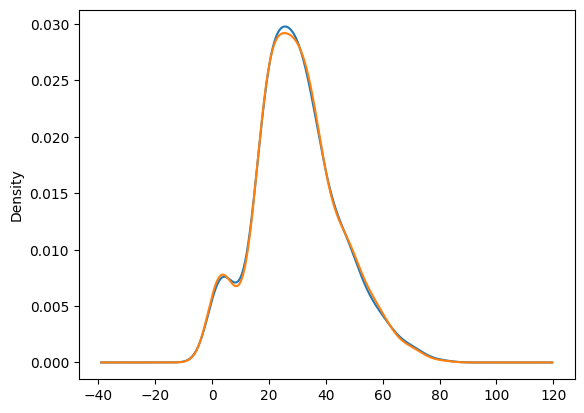

In [27]:
x_train['Age'].plot(kind='kde')
x_train['inpute_age'].plot(kind='kde')

In [29]:
print('original age variable varience is :',x_train['Age'].var())
print('age varience after random imputaion : ',x_train['inpute_age'].var())

original age variable varience is : 213.7165085187575
age varience after random imputaion :  214.41916157255966


In [30]:
x_train.cov()

,Age,Fare,inpute_age
Age,213.716509,84.480223,213.716509
Fare,84.480223,2574.352621,53.965136
inpute_age,213.716509,53.965136,214.419162


<Axes: >

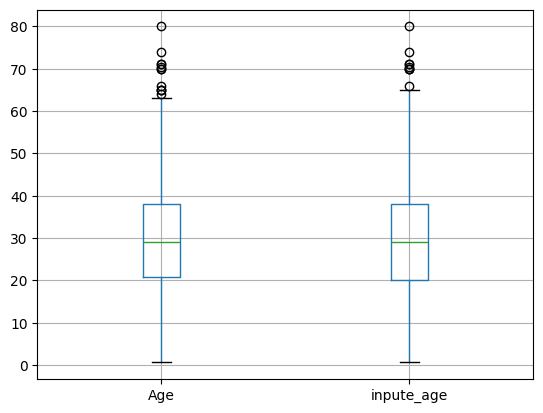

In [32]:
x_train[['Age','inpute_age']].boxplot()